<a href="https://colab.research.google.com/github/ancestor9/2026_Fall_Deep-Learning-with-Python/blob/main/scripts/Perceptron_1957_to_AlexNet_2012.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
! pip install mglearn -q

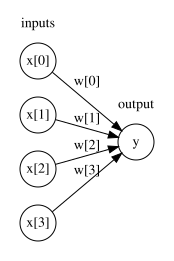

In [10]:
# @title **1. Perceptron**
import mglearn
mglearn.plot_nn_graphs.plot_logistic_regression_graph()

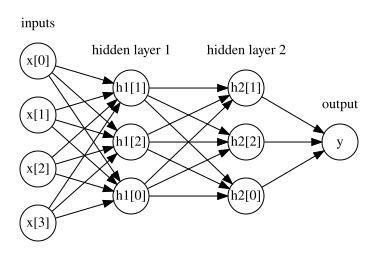

In [11]:
mglearn.plot_nn_graphs.plot_two_hidden_layer_graph()

<img src="https://camo.githubusercontent.com/3b98a2fac6c46e22d6db784aacc1edb1b3801279dec45baa888abb83d4035723/68747470733a2f2f7777772e6f7265696c6c792e636f6d2f6170692f76322f65707562732f393738313738383239393837392f66696c65732f6173736574732f30326664353332622d363836372d343365352d386536382d3161666337616163633431652e706e67">

<img src= "https://upload.wikimedia.org/wikipedia/commons/b/b2/Perceptron_XOR.jpg">

In [12]:
# @title **2. Perceptron with Hidden Layer to Solve XOR Problem**
import numpy as np
from sklearn.neural_network import MLPClassifier

# XOR 입력 데이터와 출력 데이터 정의
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

# 은닉층 1개, 노드 2개, solver 알고리즘에 따라 틀림
mlp = MLPClassifier(
    hidden_layer_sizes=(2,),
    activation='tanh',
    solver='lbfgs',
    random_state=1
)

mlp.fit(X, y)

# 예측 결과 출력
predictions = mlp.predict(X)

print("Input:")
print(X)
print("\nActual Output:")
print(y)
print("\nMLP Predicted Output:")
print(predictions)
print(f"\nAccuracy: {mlp.score(X, y) * 100}%")

Input:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Actual Output:
[0 1 1 0]

MLP Predicted Output:
[0 1 1 0]

Accuracy: 100.0%


In [13]:
# @title **3. Backpropagation with Stochastic Gradient Descent**

# 1. XOR 데이터셋 준비
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

# 활성화 함수 및 미분식 정의
def tanh(x):
    return np.tanh(x)

def tanh_deriv(x):
    return 1.0 - np.tanh(x)**2

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)

# 2. 하이퍼파라미터 및 가중치 초기화
np.random.seed(42)
lr = 0.5            # 학습률 (Learning Rate)
epochs = 5000       # 에포크 수

# W1: 입력(2) -> 은닉(2), W2: 은닉(2) -> 출력(1)
W1 = np.random.uniform(-1, 1, (2, 2))
b1 = np.zeros((1, 2))

W2 = np.random.uniform(-1, 1, (2, 1))
b2 = np.zeros((1, 1))

# 3. 학습 루프 (SGD: 각 샘플마다 가중치 업데이트)
for epoch in range(epochs):
    # SGD 구현을 위해 매 에포크마다 데이터 순서 셔플링
    indices = np.arange(len(X))
    np.random.shuffle(indices)

    for i in indices:
        x_i = X[i:i+1]  # (1, 2)
        y_i = y[i:i+1]  # (1, 1)

        # --- [Forward Pass (순전파)] ---
        z1 = np.dot(x_i, W1) + b1
        a1 = tanh(z1)                     # 은닉층 출력 (1, 2)

        z2 = np.dot(a1, W2) + b2
        a2 = sigmoid(z2)                  # 최종 출력 (1, 1)

        # --- [Backpropagation (역전파)] ---
        # 출력층 오차 및 그래디언트
        error_output = a2 - y_i
        delta2 = error_output * sigmoid_deriv(z2)  # dL/dz2

        # 은닉층 오차 및 그래디언트
        error_hidden = np.dot(delta2, W2.T)
        delta1 = error_hidden * tanh_deriv(z1)     # dL/dz1

        # --- [Weight Update (SGD 가중치 갱신)] ---
        W2 -= lr * np.dot(a1.T, delta2)
        b2 -= lr * delta2

        W1 -= lr * np.dot(x_i.T, delta1)
        b1 -= lr * delta1

# 4. 검증 및 결과 확인
print("=== XOR 예측 결과 ===")
for i in range(len(X)):
    x_i = X[i:i+1]
    a1 = tanh(np.dot(x_i, W1) + b1)
    pred = sigmoid(np.dot(a1, W2) + b2)
    binary_pred = 1 if pred >= 0.5 else 0
    print(f"입력: {X[i]} -> 예측 확률: {pred[0][0]:.4f} => 최종 분류: {binary_pred}")

=== XOR 예측 결과 ===
입력: [0 0] -> 예측 확률: 0.0116 => 최종 분류: 0
입력: [0 1] -> 예측 확률: 0.9850 => 최종 분류: 1
입력: [1 0] -> 예측 확률: 0.9850 => 최종 분류: 1
입력: [1 1] -> 예측 확률: 0.0103 => 최종 분류: 0


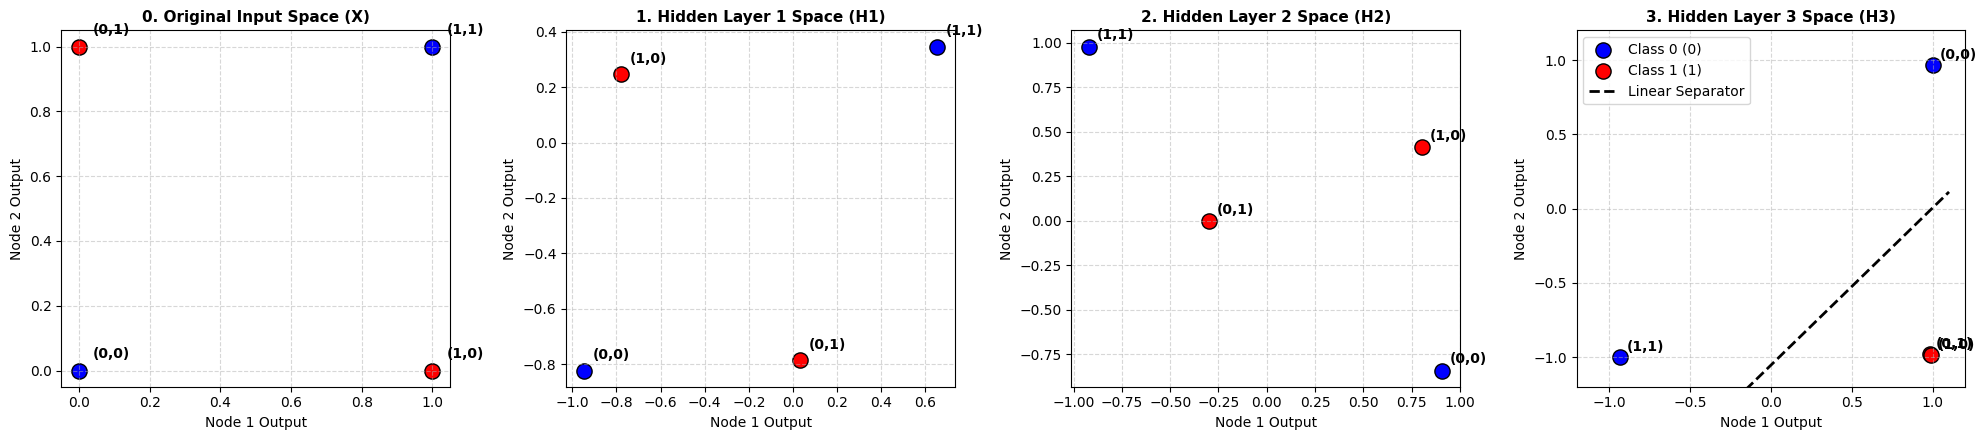

In [14]:
# @title **4. Data Representation with Hidden Layers(Non-Linear)**

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

# 1. XOR 데이터 준비
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

# 2. 은닉층 3개 (각 노드 2개) MLP 모델 생성 및 학습
mlp = MLPClassifier(
    hidden_layer_sizes=(2, 2, 2),
    activation='tanh',
    solver='lbfgs',
    random_state=42
)
mlp.fit(X, y)

# 3. 각 은닉층(Layer 1, 2, 3)을 거친 출력값 계산 함수
def forward_pass_layers(X, mlp):
    # Layer 1
    h1 = np.tanh(X @ mlp.coefs_[0] + mlp.intercepts_[0])
    # Layer 2
    h2 = np.tanh(h1 @ mlp.coefs_[1] + mlp.intercepts_[1])
    # Layer 3
    h3 = np.tanh(h2 @ mlp.coefs_[2] + mlp.intercepts_[2])
    return h1, h2, h3

H1, H2, H3 = forward_pass_layers(X, mlp)

# 4. 시각화 (4개 Subplot: 입력공간 + 은닉층 1, 2, 3)
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

titles = [
    "0. Original Input Space (X)",
    "1. Hidden Layer 1 Space (H1)",
    "2. Hidden Layer 2 Space (H2)",
    "3. Hidden Layer 3 Space (H3)"
]

data_spaces = [X, H1, H2, H3]
labels = ['(0,0)', '(0,1)', '(1,0)', '(1,1)']

for idx, ax in enumerate(axes):
    data = data_spaces[idx]

    # Class 0 (파란색), Class 1 (빨간색) 점 시각화
    ax.scatter(data[y==0, 0], data[y==0, 1], color='blue', s=120, edgecolors='k', label='Class 0 (0)')
    ax.scatter(data[y==1, 0], data[y==1, 1], color='red', s=120, edgecolors='k', label='Class 1 (1)')

    # 각 좌표 이름 표시
    for i, txt in enumerate(labels):
        ax.annotate(txt, (data[i, 0] + 0.04, data[i, 1] + 0.04), fontsize=10, weight='bold')

    ax.set_title(titles[idx], fontsize=11, weight='bold')
    ax.set_xlabel("Node 1 Output")
    ax.set_ylabel("Node 2 Output")
    ax.grid(True, linestyle='--', alpha=0.5)

# 마지막 Hidden Layer 3에는 결정 경계(직선) 추가
# W3*H3 + b = 0
W3 = mlp.coefs_[3]
b3 = mlp.intercepts_[3]
h3_vals = np.linspace(-1.1, 1.1, 100)
if W3[1, 0] != 0:
    h3_2_vals = -(W3[0, 0] * h3_vals + b3[0]) / W3[1, 0]
    axes[3].plot(h3_vals, h3_2_vals, 'k--', linewidth=2, label='Linear Separator')

axes[3].set_xlim([-1.2, 1.2])
axes[3].set_ylim([-1.2, 1.2])
axes[3].legend(loc='upper left')

plt.tight_layout()
plt.show()

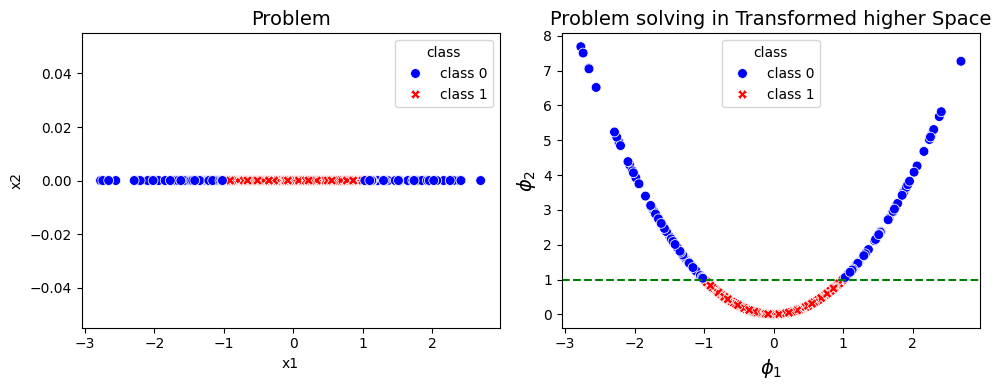

In [15]:
# @title **5. Supprot Vector Machine**
import pandas as pd
import seaborn as sns

np.random.seed(0)
X = np.random.randn(500)
tr = 1

# 1. 데이터프레임 생성
df = pd.DataFrame({
    'x1': X,
    'x2': 0,
    'phi1': X,
    'phi2': X**2,
    'class': np.where((X < tr) & (X > -tr), 'class 1', 'class 0')
})
# 2. Seaborn 시각화 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.scatterplot(data=df, x='x1', y='x2', hue='class', style='class',
                palette={'class 1': 'r', 'class 0': 'b'}, ax=axes[0], s=50)
axes[0].set_title('Problem', fontsize=14)
sns.scatterplot(data=df, x='phi1', y='phi2', hue='class', style='class',
                palette={'class 1': 'r', 'class 0': 'b'}, ax=axes[1], s=50)
axes[1].axhline(y=tr, color='g', linestyle='--')
axes[1].set_xlabel(r'$\phi_1$', fontsize=14)
axes[1].set_ylabel(r'$\phi_2$', fontsize=14)
axes[1].set_title('Problem solving in Transformed higher Space', fontsize=14)

plt.tight_layout()
plt.show()

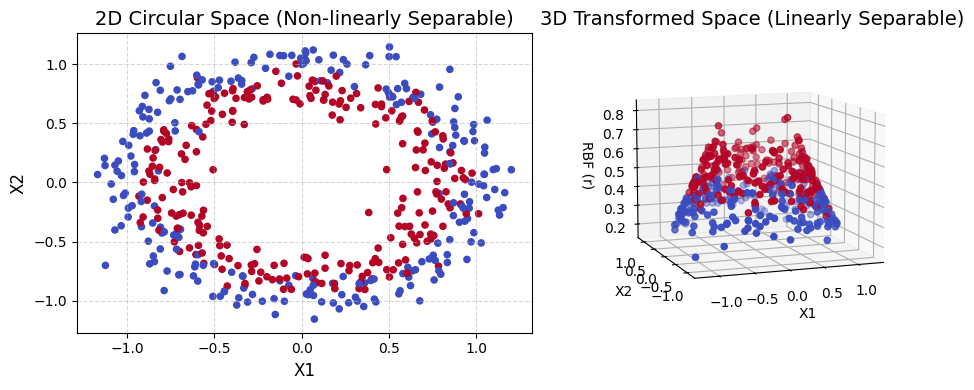

In [16]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=500, random_state=11, noise=0.1)
r = np.exp(-(X ** 2).sum(1))

fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_subplot(1, 2, 1)
scatter1 = ax1.scatter(X[:, 0], X[:, 1], c=y, s=20, cmap='coolwarm')
ax1.set_xlabel('X1', fontsize=12)
ax1.set_ylabel('X2', fontsize=12)
ax1.set_title('2D Circular Space (Non-linearly Separable)', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
scatter2 = ax2.scatter3D(X[:, 0], X[:, 1], r, c=y, s=20, cmap='coolwarm')
ax2.view_init(10, 250)
ax2.set_xlabel('X1', fontsize=10)
ax2.set_ylabel('X2', fontsize=10)
ax2.set_zlabel('RBF (r)', fontsize=10)
ax2.set_title('3D Transformed Space (Linearly Separable)', fontsize=14)

plt.tight_layout()
plt.show()

In [17]:
# @title **6. Supprot Vector Machine with MNIST**
from sklearn import datasets, svm, metrics
digits = datasets.load_digits()
data = digits.images.reshape((len(digits.images), -1))
digits = datasets.load_digits()
pd.DataFrame(digits.data, columns=[digits.feature_names]).head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


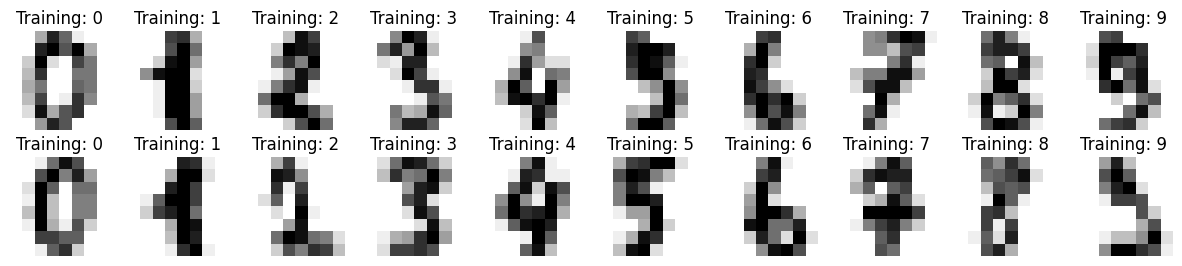

In [18]:
_, axes = plt.subplots(nrows=2, ncols=10, figsize=(15, 3))
for ax, image, label in zip(axes.flat, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title("Training: %i" % label)

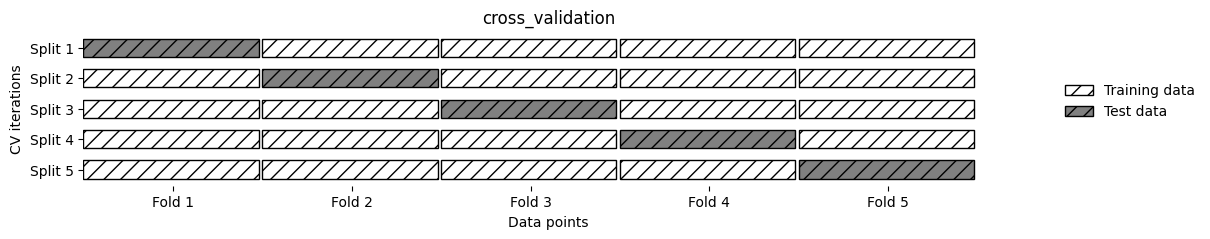

In [19]:
mglearn.plots.plot_cross_validation()

In [20]:
from sklearn.model_selection import train_test_split
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))
X_train, X_test, y_train, y_test = train_test_split(data, digits.target, test_size=0.2, shuffle=False)

clf = svm.SVC(gamma=0.001)
clf.fit(X_train, y_train)
predicted = clf.predict(X_test)
metrics.accuracy_score(y_test, predicted)

0.9583333333333334

              precision    recall  f1-score   support

           0      1.000     0.971     0.986        35
           1      0.973     1.000     0.986        36
           2      1.000     1.000     1.000        35
           3      0.968     0.811     0.882        37
           4      0.971     0.919     0.944        37
           5      0.925     1.000     0.961        37
           6      1.000     1.000     1.000        37
           7      0.973     1.000     0.986        36
           8      0.838     0.939     0.886        33
           9      0.946     0.946     0.946        37

    accuracy                          0.958       360
   macro avg      0.959     0.959     0.958       360
weighted avg      0.960     0.958     0.958       360



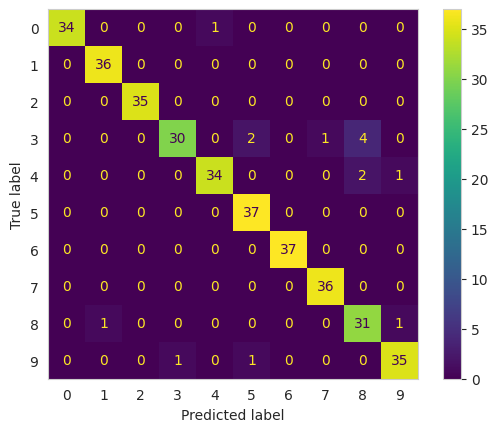

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, average_precision_score
sns.set_style("whitegrid", {'axes.grid' : False})
print(classification_report(y_test, predicted, digits=3))
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)

In [22]:
# @title **7. Fully Connected Neural Network with MNIST**
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical

# 1. 데이터 정규화 및 One-hot 인코딩
X_train_scaled = X_train / 16.0
X_test_scaled = X_test / 16.0

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

# 2. 최신 Keras 표준 방식에 맞춰 Input 레이어 적용
model = Sequential([
    Input(shape=(64,)), # 경고 해결을 위한 명시적 Input 선언
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

# 3. 모델 컴파일
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. 모델 학습
history = model.fit(
    X_train_scaled, y_train_cat,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# 5. 테스트 정확도 평가
loss, accuracy = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print("\n" + "="*40)
print(f"Keras Deep Learning Test Accuracy (Clean): {accuracy * 100:.3f}%")
print("="*40)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.3712 - loss: 2.0316 - val_accuracy: 0.7708 - val_loss: 1.5919
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7154 - loss: 1.2271 - val_accuracy: 0.9444 - val_loss: 0.6870
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8314 - loss: 0.6514 - val_accuracy: 0.9375 - val_loss: 0.3819
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8886 - loss: 0.4478 - val_accuracy: 0.9583 - val_loss: 0.2444
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9018 - loss: 0.3419 - val_accuracy: 0.9444 - val_loss: 0.2106
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9288 - loss: 0.2727 - val_accuracy: 0.9444 - val_loss: 0.1752
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9350 - loss: 0.2454 - val_accuracy: 0.9653 - val_loss: 0.1358
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9335 - loss: 0.2264 - val_accuracy: 0.9792 - val_los

In [23]:
# @title **8. Convolutional Neural Network with MNIST**
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn import datasets
from sklearn.model_selection import train_test_split

# 1. 데이터 가져오기 및 분할 (NameError 방지를 위해 내부에 명시적 로드 추가)
digits = datasets.load_digits()
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

# 데이터 분할 (기존과 동일한 8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(data, digits.target, test_size=0.2, shuffle=False)

# 2. 2D CNN을 위한 데이터 전처리 (정규화 및 8x8x1 형태로 변환)
X_train_cnn = X_train.reshape(-1, 8, 8, 1) / 16.0
X_test_cnn = X_test.reshape(-1, 8, 8, 1) / 16.0

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

# 3. 고정밀 분류를 위한 최적화된 CNN 레이어 설계
optimized_cnn = Sequential([
    Input(shape=(8, 8, 1)),

    # 첫 번째 Conv 블록
    Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # 두 번째 Conv 블록
    Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Dense 분류기
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(10, activation='softmax')
])

# 4. 모델 컴파일
optimized_cnn.compile(
    optimizer=Adam(learning_rate=0.002),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. 성능 극대화를 위한 콜백 설정
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# 6. 모델 학습 수행 (에포크 증가 및 콜백 적용)
history = optimized_cnn.fit(
    X_train_cnn, y_train_cat,
    epochs=60,
    batch_size=16,
    validation_split=0.1,
    callbacks=[lr_scheduler, early_stopping],
    verbose=1
)

# 7. 최종 테스트 데이터 평가 및 결과 확인
loss, accuracy = optimized_cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)
print("\n" + "="*40)
print(f"Fully Optimized CNN Test Accuracy: {accuracy * 100:.3f}%")
print("="*40)

Epoch 1/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 22s 114ms/step - accuracy: 0.6667 - loss: 1.0654 - val_accuracy: 0.1042 - val_loss: 2.3439 - learning_rate: 0.0020
Epoch 2/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8971 - loss: 0.3273 - val_accuracy: 0.3056 - val_loss: 2.1051 - learning_rate: 0.0020
Epoch 3/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9443 - loss: 0.1701 - val_accuracy: 0.4653 - val_loss: 1.6383 - learning_rate: 0.0020
Epoch 4/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9675 - loss: 0.1271 - val_accuracy: 0.6944 - val_loss: 0.9955 - learning_rate: 0.0020
Epoch 5/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9652 - loss: 0.1063 - val_accuracy: 0.7639 - val_loss: 0.8236 - learning_rate: 0.0020
Epoch 6/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9753 - loss: 0.0904 - val_accuracy: 0.9931 - val_loss: 0.0378 - learning_rate: 0.0020
Epoch 7/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9722 - loss: 0.0919 - val_accurac

In [1]:
# @title **8. LeNet-5 & AlexNet(Pre-trained CNN + Fine Tunning)  with MNIST**

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# 1. 장치 설정 (GPU / CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. 데이터 전처리 설정
# AlexNet 등 ImageNet 사전학습 모델은 3채널, 224x224 규격 및 표준화를 권장합니다.
transform_alexnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # 1채널 -> 3채널 변환
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# LeNet-5용 전처리 (기본 28x28 또는 32x32)
transform_lenet = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 3. LeNet-5 모델 정의
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1),
            nn.Tanh()
        )
        self.classifier = nn.Sequential(
            nn.Linear(in_features=120, out_features=84),
            nn.Tanh(),
            nn.Linear(in_features=84, out_features=10)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        logits = self.classifier(x)
        return logits

# 4. AlexNet Pretrained 모델 로드 및 출력층 변경
def get_pretrained_alexnet():
    # PyTorch 최신 버전 기준 weights 파라미터 사용
    model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
    # 마지막 Classifier 레이어를 MNIST 클래스 수(10개)로 변경
    model.classifier[6] = nn.Linear(4096, 10)
    return model

# 5. 학습 및 평가 함수
def train_and_evaluate(model, train_loader, test_loader, epochs=3, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f}")

    # 평가 진행
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

# 6. 메인 실행 루틴
if __name__ == "__main__":
    batch_size = 64
    epochs = 3

    # --- [1] LeNet-5 학습 및 평가 ---
    print("\n=== 1. LeNet-5 Training ===")
    train_ds_lenet = datasets.MNIST(root="./data", train=True, download=True, transform=transform_lenet)
    test_ds_lenet = datasets.MNIST(root="./data", train=False, download=True, transform=transform_lenet)

    train_loader_lenet = DataLoader(train_ds_lenet, batch_size=batch_size, shuffle=True)
    test_loader_lenet = DataLoader(test_ds_lenet, batch_size=batch_size, shuffle=False)

    lenet_model = LeNet5()
    lenet_acc = train_and_evaluate(lenet_model, train_loader_lenet, test_loader_lenet, epochs=epochs)
    print(f"LeNet-5 Test Accuracy: {lenet_acc:.2f}%")

    # --- [2] Pretrained AlexNet 학습 및 평가 ---
    print("\n=== 2. Pretrained AlexNet Fine-tuning ===")
    train_ds_alex = datasets.MNIST(root="./data", train=True, download=True, transform=transform_alexnet)
    test_ds_alex = datasets.MNIST(root="./data", train=False, download=True, transform=transform_alexnet)

    train_loader_alex = DataLoader(train_ds_alex, batch_size=batch_size, shuffle=True)
    test_loader_alex = DataLoader(test_ds_alex, batch_size=batch_size, shuffle=False)

    alexnet_model = get_pretrained_alexnet()
    alexnet_acc = train_and_evaluate(alexnet_model, train_loader_alex, test_loader_alex, epochs=epochs, lr=0.0001)
    print(f"Pretrained AlexNet Test Accuracy: {alexnet_acc:.2f}%")

Using device: cuda

=== 1. LeNet-5 Training ===
Epoch [1/3] - Loss: 0.2428
Epoch [2/3] - Loss: 0.0678
Epoch [3/3] - Loss: 0.0477
LeNet-5 Test Accuracy: 98.58%

=== 2. Pretrained AlexNet Fine-tuning ===
Epoch [1/3] - Loss: 0.0814
Epoch [2/3] - Loss: 0.0307
Epoch [3/3] - Loss: 0.0242
Pretrained AlexNet Test Accuracy: 99.40%


In [2]:
# @title 9. Fully_Convolutional_Network
# https://github.com/ancestor9/2026_Fall_Deep-Learning-with-Python/blob/main/scripts/Fully_Convolutional_Network_FCN.ipynb